In [11]:
import re
from pathlib import Path
import numpy as np
from PIL import Image

# ==========================================
# НАСТРОЙКИ ПУТЕЙ
# ==========================================
BASE_DIR = Path(r"C:\Users\RedBrean\Documents\MIPT\term2\MQO\experiment_srochnii")
INPUT_DIR = Path(r"C:\Users\RedBrean\Pictures\RQC\2026-07-16")
OUTPUT_DIR = BASE_DIR / "processed"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ==========================================
# ФУНКЦИИ ОБРАБОТКИ ИЗОБРАЖЕНИЙ
# ==========================================

def load_image(filepath: Path) -> np.ndarray:
    """Загружает PNG изображение как float64 массив."""
    with Image.open(filepath) as img:
        return np.array(img, dtype=np.float64)


def combine_images(filepaths: list[Path], method: str = "median") -> np.ndarray:
    """
    Объединяет стек изображений.
    'median' убирает случайные шумы, горячие и битые пиксели.
    """
    if not filepaths:
        raise ValueError("Список файлов для объединения пуст.")
    
    stack = np.stack([load_image(f) for f in filepaths])
    
    if method == "median":
        return np.median(stack, axis=0)
    return np.mean(stack, axis=0)


def save_image(arr: np.ndarray, filepath: Path) -> None:
    """Сохраняет массив как PNG, автоматически определяя разрядность (8/16 бит)."""
    # Обрезаем значения, чтобы не вылететь за границы uint16
    arr_clipped = np.clip(arr, 0, 65535)

    # Добавляем небольшой epsilon (0.1) для защиты от погрешности float при усреднении
    if arr_clipped.max() <= 255.1:
        arr_rescaled = arr_clipped.astype(np.uint8)
    else:
        # Для 16-битных RGB изображений (PIL не умеет в 16-bit RGB)
        if len(arr_clipped.shape) == 3 and arr_clipped.shape[2] == 3:
            arr_max = arr_clipped.max()
            arr_rescaled = (arr_clipped / arr_max * 255.0).astype(np.uint8) if arr_max > 0 else arr_clipped.astype(np.uint8)
        else:
            arr_rescaled = arr_clipped.astype(np.uint16)

    Image.fromarray(arr_rescaled).save(filepath)

# ==========================================
# ГРУППИРОВКА ФАЙЛОВ
# ==========================================

groups = {}

# Регулярное выражение ловит группы (включая дробные), типы кадров и любой хвост с датой/миллисекундами
pattern = re.compile(r"^([\d_.-]+?)(_(?:FN|F|N))?_\d{4}-\d{2}-\d{2}T.*$")

for file in INPUT_DIR.glob("*.png"):
    name = file.stem
    
    # Игнорируем служебные файлы инициализации
    if name.startswith("INIT"):
        continue
        
    match = pattern.match(name)
    
    if match:
        key = match.group(1)       # Например, "1_0" или "1_44.95"
        suffix = match.group(2)    # Например, "_FN", "_F", "_N" или None
        
        if suffix == "_N":
            kind = "noise"
        elif suffix == "_F":
            kind = "flat"
        elif suffix == "_FN":
            kind = "flat_noise"
        else:
            kind = "signal"
            
        groups.setdefault(key, {"signal": [], "noise": [], "flat": [], "flat_noise": []})
        groups[key][kind].append(file)
    else:
        print(f"Предупреждение: Файл {file.name} не соответствует шаблону имени!")

# ==========================================
# ОСНОВНОЙ ЦИКЛ ОБРАБОТКИ
# ==========================================

print(f"Старт обработки файлов из: {INPUT_DIR}\n" + "-"*50)

for key, data in sorted(groups.items()):
    signal_files = data["signal"]
    noise_files = data["noise"]
    flat_files = data["flat"]
    flat_noise_files = data["flat_noise"]

    # Проверяем, есть ли хоть какие-то данные для этой группы
    if not signal_files and not flat_files:
        print(f"Предупреждение: Для группы '{key}' нет ни сигналов, ни флэтов. Пропускаем.")
        continue

    print(f"Обработка группы: {key}")
    
    # --- 1. ОБРАБОТКА СИГНАЛА (Получаем чистый сигнал) ---
    if signal_files:
        print(f"  ├─ Сигнал: {len(signal_files)} кадров | Шум (N): {len(noise_files)} кадров")
        signal_avg = combine_images(signal_files, method="median")
        if noise_files:
            noise_avg = combine_images(noise_files, method="median")
            signal_clean = np.maximum(signal_avg - noise_avg, 0)
        else:
            signal_clean = signal_avg
            
        # Сохраняем чистый сигнал (имя группы без суффиксов)
        save_image(signal_clean, OUTPUT_DIR / f"{key}.png")
    else:
        print(f"  ├─ Сигнальные кадры отсутствуют.")

    # --- 2. ОБРАБОТКА ФЛЭТА (Получаем чистый флэт) ---
    if flat_files:
        print(f"  └─ Флэт (F): {len(flat_files)} кадров | Шум флэта (FN): {len(flat_noise_files)} кадров")
        flat_avg = combine_images(flat_files, method="median")
        if flat_noise_files:
            flat_noise_avg = combine_images(flat_noise_files, method="median")
            flat_clean = np.maximum(flat_avg - flat_noise_avg, 0)
        else:
            flat_clean = flat_avg
            
        # Сохраняем чистый флэт с суффиксом "_F"
        save_image(flat_clean, OUTPUT_DIR / f"{key}_F.png")
    else:
        print(f"  └─ Кадры флэта отсутствуют.")

print("-"*50)
print("Готово! Очищенные пары кадров сохранены в:")
print(OUTPUT_DIR)

Старт обработки файлов из: C:\Users\RedBrean\Pictures\RQC\2026-07-16
--------------------------------------------------
Обработка группы: 1_0
  ├─ Сигнал: 5 кадров | Шум (N): 5 кадров
  └─ Флэт (F): 5 кадров | Шум флэта (FN): 5 кадров
Обработка группы: 1_12
  ├─ Сигнал: 5 кадров | Шум (N): 5 кадров
  └─ Флэт (F): 5 кадров | Шум флэта (FN): 5 кадров
Обработка группы: 1_15
  ├─ Сигнал: 5 кадров | Шум (N): 5 кадров
  └─ Флэт (F): 5 кадров | Шум флэта (FN): 5 кадров
Обработка группы: 1_18
  ├─ Сигнал: 5 кадров | Шум (N): 5 кадров
  └─ Флэт (F): 5 кадров | Шум флэта (FN): 5 кадров
Обработка группы: 1_21
  ├─ Сигнал: 5 кадров | Шум (N): 5 кадров
  └─ Флэт (F): 5 кадров | Шум флэта (FN): 5 кадров
Обработка группы: 1_24
  ├─ Сигнал: 5 кадров | Шум (N): 5 кадров
  └─ Флэт (F): 5 кадров | Шум флэта (FN): 5 кадров
Обработка группы: 1_27
  ├─ Сигнал: 5 кадров | Шум (N): 5 кадров
  └─ Флэт (F): 5 кадров | Шум флэта (FN): 5 кадров
Обработка группы: 1_3
  ├─ Сигнал: 5 кадров | Шум (N): 5 кадров
  └─ 

In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns  # Удобно для красивых графиков с группировкой
from scipy.optimize import curve_fit
from scipy.signal import find_peaks, savgol_filter
from sklearn.metrics import r2_score


class CrystalExperiment:
    """
    Класс отдельного эксперимента.
    Хранит метаданные в виде произвольного словаря, осуществляет калибровку
    и анализ интерференционной картины. Все результаты сохраняются в поля класса.
    """
    C_LIGHT = 299_792_458

    def __init__(self, filter_filename, nofilter_filename, metadata=None, config=None):
        self.filter_filename = filter_filename
        self.nofilter_filename = nofilter_filename
        
        # Хранилище для любых параметров эксперимента (дистанция, щель, ток и т.д.)
        self.metadata = metadata if metadata is not None else {}
        
        if config is None:
            config = {
                "left": 250, "right": 370,
                "top": 140, "bottom": 275,
                "target_wavelength": 808.0,
                "output_dir": "analysis_output",
                "stripe_width": 3,
                "savgol_window": 13,
                "savgol_poly": 2,
                "peak_prominence": 0.008,
                "valley_prominence": 0.008,
                "peak_distance": 6,
                "peak_height_min": 0.12
            }
        self.config = config

        self.filter_dir = os.path.join(config["output_dir"], "filter_fits")
        self.nofilter_dir = os.path.join(config["output_dir"], "nofilter_spectra")

        # --- ПОЛЯ КЛАССА ДЛЯ ХРАНЕНИЯ РЕЗУЛЬТАТОВ ---
        # Результаты калибровки (Fit)
        self.alpha = None
        self.beta = None
        self.shift = None
        self.scale = None
        self.r2 = None
        
        # Массивы данных
        self.img_nf = None
        self.crop_nf = None
        self.spectrum_nf = None
        self.slice_808 = None
        self.smoothed_slice = None
        
        # Экстремумы и координаты
        self.pixel808 = None
        self.peaks_idx = []
        self.valleys_idx = []
        self.paired_extrema = []  
        self.local_visibilities = []

        # Ключевые физические метрики
        self.visibility = 0.0
        self.intensity_max_slice = 0.0  
        self.intensity_808_exact = 0.0
        self.intensity_808_avg = 0.0
        self.intensity_total = 0.0
        
        self.log_line = ""

    @staticmethod
    def _gaussian(w, w0, sig):
        return np.exp(-0.5 * ((w - w0) / sig) ** 2)

    @staticmethod
    def _convert_w_to_l(func, w_range, *params):
        l_range = 2 * np.pi * CrystalExperiment.C_LIGHT / w_range * 1e-3
        y_w = func(w_range, *params)
        y_l = y_w / l_range**2
        y_l /= np.max(y_l)
        return y_l

    @staticmethod
    def _gfit(pix, alpha, beta, shift, scale):
        wavelength = shift + scale * pix
        c_factor = 2 * np.pi * CrystalExperiment.C_LIGHT * 1e-3
        ang_freq = c_factor / wavelength
        l0 = 810
        l_fwhm = 10
        w0 = c_factor / l0
        w_fwhm = c_factor * l_fwhm / (l0**2 - (l_fwhm / 2)**2)
        sig_w = w_fwhm / (2 * np.sqrt(2 * np.log(2)))
        y_l = CrystalExperiment._convert_w_to_l(CrystalExperiment._gaussian, ang_freq, w0, sig_w)
        y_l /= np.max(y_l)
        return beta + alpha * y_l

    def _load_image(self, filename):
        img = Image.open(f"processed/{filename}").convert("L")
        img = np.array(img, dtype=float)
        img /= np.max(img)
        return img

    def _get_crop(self, img):
        return img[self.config["top"]:self.config["bottom"], self.config["left"]:self.config["right"]]

    def _get_meta_string(self):
        """Красивая строка со всеми параметрами для графиков и логов"""
        if not self.metadata:
            return "No Meta"
        return ", ".join([f"{k}: {v}" for k, v in self.metadata.items()])

    def run_calibration(self):
        img = self._load_image(self.filter_filename)
        crop = self._get_crop(img)
        x_pix = np.arange(self.config["left"], self.config["right"])
        y_exp = np.trapezoid(crop, axis=0)
        y_exp /= np.max(y_exp)



        p0 = [1.0, 0.1, 738, 0.2]
        popt, _ = curve_fit(self._gfit, x_pix, y_exp, p0=p0, maxfev=10000)
        y_fit = self._gfit(x_pix, *popt)
        
        # Сохраняем результаты калибровки в явные поля класса
        self.alpha = popt[0]
        self.beta = popt[1]
        self.shift = popt[2]
        self.scale = popt[3]
        self.r2 = r2_score(y_exp, y_fit)
        
        # Временный контекст для отрисовки локального графика калибровки
        self._tmp_calib = {"image": img, "crop": crop, "x_pix": x_pix, "y_exp": y_exp, "y_fit": y_fit}

    def process_nofilter_data(self):
        if self.shift is None or self.scale is None:
            raise ValueError("Калибровка не проведена или завершилась с ошибкой!")

        self.img_nf = self._load_image(self.nofilter_filename)
        self.crop_nf = self._get_crop(self.img_nf)
        self.spectrum_nf = np.trapezoid(self.crop_nf, axis=0)

        self.pixel808 = (self.config["target_wavelength"] - self.shift) / self.scale
        pixel_local = int(round(self.pixel808)) - self.config["left"]

        # 1. Метрики интенсивности из горизонтального спектра
        if 0 <= pixel_local < len(self.spectrum_nf):
            self.intensity_808_exact = self.spectrum_nf[pixel_local]
        else:
            self.intensity_808_exact = 0.0

        radius = 2
        w_start = max(0, pixel_local - radius)
        w_end = min(len(self.spectrum_nf), pixel_local + radius + 1)
        self.intensity_808_avg = np.mean(self.spectrum_nf[w_start:w_end]) if w_start < w_end else 0.0

        self.intensity_total = np.trapezoid(self.spectrum_nf)

        # 2. Вертикальный срез интерференции (анализ по оси Y)
        half_width = self.config["stripe_width"] // 2
        start_x = max(0, pixel_local - half_width)
        stop_x = min(self.crop_nf.shape[1], pixel_local + half_width + 1)
        self.slice_808 = np.mean(self.crop_nf[:, start_x:stop_x], axis=1)

        w_len = self.config["savgol_window"]
        p_order = self.config["savgol_poly"]
        if w_len >= len(self.slice_808):
            w_len = len(self.slice_808) if len(self.slice_808) % 2 != 0 else len(self.slice_808) - 1
        self.smoothed_slice = savgol_filter(self.slice_808, window_length=w_len, polyorder=p_order)

        self.intensity_max_slice = np.max(self.smoothed_slice)

        # 3. Поиск экстремумов интерференции
        peaks, _ = find_peaks(
            self.smoothed_slice, 
            prominence=self.config["peak_prominence"], 
            distance=self.config["peak_distance"],
            height=self.config["peak_height_min"]
        )
        self.peaks_idx = peaks

        valleys = []
        if len(peaks) >= 2:
            p_left = peaks[0]
            p_right = peaks[-1]
            valley_zone = -self.smoothed_slice[p_left:p_right]
            valleys_local, _ = find_peaks(
                valley_zone, 
                prominence=self.config["valley_prominence"], 
                distance=self.config["peak_distance"]
            )
            valleys = valleys_local + p_left
        self.valleys_idx = valleys

        extrema_list = []
        for p in peaks: extrema_list.append((p, 'max', self.smoothed_slice[p]))
        for v in valleys: extrema_list.append((v, 'min', self.smoothed_slice[v]))
        extrema_list.sort(key=lambda x: x[0])

        self.local_visibilities = []
        self.paired_extrema = []
        for i in range(len(extrema_list) - 1):
            ex1, ex2 = extrema_list[i], extrema_list[i+1]
            if ex1[1] != ex2[1]:  
                i_max = ex1[2] if ex1[1] == 'max' else ex2[2]
                i_min = ex1[2] if ex1[1] == 'min' else ex2[2]
                v_local = (i_max - i_min) / (i_max + i_min)
                self.local_visibilities.append(v_local)
                self.paired_extrema.append((ex1[0], ex2[0], ex1[1], ex2[1]))

        self.visibility = np.max(self.local_visibilities) if len(self.local_visibilities) > 0 else 0.0

        # Сборка лога с учетом метаданных
        self.log_line = (
            f"Params [{self._get_meta_string()}] | "
            f"Vis_Max={self.visibility:.4f} | "
            f"Exact_808={self.intensity_808_exact:.3f} | "
            f"Avg_808={self.intensity_808_avg:.3f}"
        )

    def save_plots(self):
        os.makedirs(self.filter_dir, exist_ok=True)
        os.makedirs(self.nofilter_dir, exist_ok=True)
        self._save_filter_plot()    
        self._save_nofilter_plot()

    def _save_filter_plot(self):
        if not hasattr(self, '_tmp_calib'): return
        res = self._tmp_calib
        info = (
            f"File: {os.path.basename(self.filter_filename)}\n"
            f"Meta: {self._get_meta_string()}\n\n"
            f"alpha = {self.alpha:.4f}\n"
            f"beta  = {self.beta:.4f}\n"
            f"shift = {self.shift:.4f} nm\n"
            f"scale = {self.scale:.6f} nm/pix\n"
            f"R²    = {self.r2:.5f}"
        )

        fig, ax = plt.subplots(2, 2, figsize=(10, 7))
        im0 = ax[0, 0].imshow(res["image"], aspect="auto")
        ax[0, 0].vlines([self.config["left"], self.config["right"]], 0, res["image"].shape[0])
        ax[0, 0].hlines([self.config["top"], self.config["bottom"]], 0, res["image"].shape[1])
        fig.colorbar(im0, ax=ax[0, 0])

        im1 = ax[0, 1].imshow(
            res["crop"],
            extent=[self.config["left"], self.config["right"], self.config["bottom"], self.config["top"]],
            aspect="auto",
        )
        fig.colorbar(im1, ax=ax[0, 1])

        ax[1, 0].plot(res["x_pix"], res["y_exp"], ".", label="Experiment")
        ax[1, 0].plot(res["x_pix"], res["y_fit"], lw=2, label="Fit")
        ax[1, 0].grid()
        ax[1, 0].legend()

        ax[1, 1].axis("off")
        ax[1, 1].text(0.05, 0.95, info, va="top", family="monospace")

        plt.tight_layout()
        out_name = os.path.basename(self.filter_filename).replace(".png", "_fit.png")
        plt.savefig(os.path.join(self.filter_dir, out_name), dpi=300)
        plt.close()
        del self._tmp_calib # Очищаем временный тяжелый массив

    def _save_nofilter_plot(self):
        fig, ax = plt.subplots(2, 2, figsize=(12, 8))

        im0 = ax[0, 0].imshow(
            self.crop_nf,
            extent=[self.config["left"], self.config["right"], self.config["bottom"], self.config["top"]],
            aspect="auto"
        )
        ax[0, 0].axvline(self.pixel808, color="red", linestyle="--", lw=1.5, label="808 nm")
        ax[0, 0].set_title(f"Crop Specs ({self._get_meta_string()})")
        ax[0, 0].legend()
        fig.colorbar(im0, ax=ax[0, 0])

        y_pix = np.arange(self.config["top"], self.config["bottom"])
        ax[0, 1].plot(y_pix, self.slice_808, color="purple", alpha=0.25, linestyle="--", label="Raw")
        ax[0, 1].plot(y_pix, self.smoothed_slice, color="purple", lw=2, label="Savitzky-Golay")
        
        y_peaks = self.config["top"] + self.peaks_idx
        y_valleys = self.config["top"] + self.valleys_idx
        
        ax[0, 1].plot(y_peaks, self.smoothed_slice[self.peaks_idx], "r^", markersize=7, label="Local Max")
        ax[0, 1].plot(y_valleys, self.smoothed_slice[self.valleys_idx], "bv", markersize=7, label="Bounded Min")

        if len(self.peaks_idx) >= 2:
            ax[0, 1].axvspan(self.config["top"] + self.peaks_idx[0], 
                             self.config["top"] + self.peaks_idx[-1], 
                             color='gainsboro', alpha=0.4, label='Valid Interference Zone')

        for idx1, idx2, _, _ in self.paired_extrema:
            y1 = self.config["top"] + idx1
            y2 = self.config["top"] + idx2
            ax[0, 1].plot([y1, y2], [self.smoothed_slice[idx1], self.smoothed_slice[idx2]], 
                         color="orange", linestyle="-", lw=1.2, alpha=0.8)

        ax[0, 1].set_title("Strict Bounded Extrema Matching")
        ax[0, 1].set_xlabel("Y coordinate (pixels)")
        ax[0, 1].set_ylabel("Intensity")
        ax[0, 1].grid(True, linestyle=":")
        ax[0, 1].legend()

        x_pix = np.arange(self.config["left"], self.config["right"])
        ax[1, 0].plot(x_pix, self.spectrum_nf, color="gray")
        ax[1, 0].axvline(self.pixel808, color="red", linestyle="--")
        ax[1, 0].set_title("Horizontal Spectrum Profile")
        ax[1, 0].grid(True)

        ax[1, 1].axis("off")
        info_text = (
            f"Parameters:\n {self._get_meta_string()}\n\n"
            f"Extrema Count:\n"
            f"  Max (peaks): {len(self.peaks_idx)}\n"
            f"  Min (bounded): {len(self.valleys_idx)}\n\n"
            f"Peak Intensity: {self.intensity_max_slice:.4f}\n"
            f"MAX VISIBILITY: V = {self.visibility:.5f}"
        )
        ax[1, 1].text(0.1, 0.8, info_text, va="top", family="monospace", fontsize=12,
                      bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.5))

        plt.tight_layout()
        out_name = os.path.basename(self.nofilter_filename).replace(".png", "_visibility.png")
        plt.savefig(os.path.join(self.nofilter_dir, out_name), dpi=200)
        plt.close()


class SpectroscopyBatchAnalyzer:
    """
    Менеджер автоматической пакетной обработки серий экспериментов.
    Умеет строить финальные зависимости по любому выбранному параметру метаданных.
    """
    def __init__(self, output_dir="analysis_output", x_param="distance"):
        self.output_dir = output_dir
        self.x_param = x_param  # Имя параметра из metadata, который будет осью X на финальных графиках
        self.experiments = []

    def add_experiment(self, exp: CrystalExperiment):
        self.experiments.append(exp)

    def process_all(self, generate_summary=False):
        os.makedirs(self.output_dir, exist_ok=True)
        for exp in self.experiments:
            print("-" * 60)
            exp.run_calibration()
            exp.process_nofilter_data()
            exp.save_plots()
            print(exp.log_line)
        if generate_summary:
            self._generate_summary_report()

    def plot_custom_report(self, x_param, y_param, group_by=None, 
                           title="Custom Plot", xlabel=None, ylabel=None, filename="custom_report.png"):
        """
        Универсальный метод для построения графиков строго точками.
        
        :param x_param: Ключ из metadata для оси X (например, 'slit_size')
        :param y_param: Имя поля класса CrystalExperiment для оси Y (например, 'visibility')
        :param group_by: Ключ из metadata для разделения на разные серии/цвета (например, 'distance')
        :param title: Заголовок графика
        :param xlabel: Подпись оси X (если None, берется имя параметра)
        :param ylabel: Подпись оси Y (если None, берется имя параметра)
        :param filename: Имя сохраняемого файла
        """
        plt.figure(figsize=(8, 5.5))
        
        # Список доступных маркеров для серий данных
        markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']
        
        if group_by:
            # Находим все уникальные значения параметра группировки
            group_values = sorted(list(set([exp.metadata.get(group_by) for exp in self.experiments if group_by in exp.metadata])))
            
            for i, g_val in enumerate(group_values):
                # Фильтруем эксперименты, относящиеся к текущей группе
                sub_exps = [e for e in self.experiments if e.metadata.get(group_by) == g_val]
                # Сортируем внутри группы по оси X
                sub_exps.sort(key=lambda e: e.metadata.get(x_param, 0.0))
                
                x_data = [e.metadata.get(x_param) for e in sub_exps]
                y_data = [getattr(e, y_param) for e in sub_exps]
                
                marker = markers[i % len(markers)]
                plt.plot(x_data, y_data, marker, markersize=8, label=f"{group_by}: {g_val}")
        else:
            # Без группировки — просто один массив точек
            self.experiments.sort(key=lambda e: e.metadata.get(x_param, 0.0))
            x_data = [e.metadata.get(x_param) for e in self.experiments]
            y_data = [getattr(e, y_param) for e in self.experiments]
            plt.plot(x_data, y_data, 'o', color='royalblue', markersize=8)

        # Кастомизация осей и сетки
        plt.title(title, fontsize=12, fontweight="bold", pad=15)
        plt.xlabel(xlabel if xlabel else x_param, fontsize=11)
        plt.ylabel(ylabel if ylabel else y_param, fontsize=11)
        plt.grid(True, linestyle=":", alpha=0.6)
        
        if group_by:
            plt.legend(frameon=True, facecolor='white', edgecolor='gainsboro')
            
        plt.tight_layout()
        save_path = os.path.join(self.output_dir, filename)
        plt.savefig(save_path, dpi=300)
        plt.close()
        print(f"[График сохранен] -> {save_path}")

    def _generate_summary_report(self):
        if not self.experiments:
            print("Нет данных для финального отчета.")
            return

        # Сортируем эксперименты по значению выбранного X-параметра (например, по дистанции)
        self.experiments.sort(key=lambda x: x.metadata.get(self.x_param, 0.0))

        # Собираем массивы для графиков напрямую из полей классов
        x_values = np.array([exp.metadata.get(self.x_param, 0.0) for exp in self.experiments])
        visibilities = np.array([exp.visibility for exp in self.experiments])
        intensities_exact = np.array([exp.intensity_808_exact for exp in self.experiments])
        intensities_avg = np.array([exp.intensity_808_avg for exp in self.experiments])
        intensities_total = np.array([exp.intensity_total for exp in self.experiments])

        x_label = f"Experimental Parameter: '{self.x_param}'"

        # ---- ГРАФИК №1: МАКСИМАЛЬНАЯ ВИДНОСТЬ ----
        plt.figure(figsize=(7, 4.5))
        plt.plot(x_values, visibilities, "o", color="forestgreen", markersize=8)
        plt.xlabel(x_label, fontsize=11)
        plt.ylabel("Maximum Local Visibility (V)", fontsize=11)
        plt.title(f"Maximum Visibility vs {self.x_param}", fontsize=12, fontweight="bold")
        plt.grid(True, linestyle=":", alpha=0.6)
        plt.tight_layout()
        plt.savefig(os.path.join(self.output_dir, f"report_visibility_by_{self.x_param}.png"), dpi=300)
        plt.close()

        # ---- ГРАФИК №2: СТРОГАЯ ИНТЕНСИВНОСТЬ 808 НМ ----
        plt.figure(figsize=(7, 4.5))
        plt.plot(x_values, intensities_exact, "s", color="crimson", markersize=8)
        plt.xlabel(x_label, fontsize=11)
        plt.ylabel("Exact Intensity at 808 nm (a.u.)", fontsize=11)
        plt.title(f"Exact 808 nm Intensity vs {self.x_param}", fontsize=12, fontweight="bold")
        plt.grid(True, linestyle=":", alpha=0.6)
        plt.tight_layout()
        plt.savefig(os.path.join(self.output_dir, f"report_intensity_exact_by_{self.x_param}.png"), dpi=300)
        plt.close()

        # ---- ГРАФИК №3: УСРЕДНЕННАЯ ИНТЕНСИВНОСТЬ 808 НМ ----
        plt.figure(figsize=(7, 4.5))
        plt.plot(x_values, intensities_avg, "^", color="orangered", markersize=8)
        plt.xlabel(x_label, fontsize=11)
        plt.ylabel("Averaged Intensity at 808 nm (a.u.)", fontsize=11)
        plt.title(f"Averaged 808 nm Intensity vs {self.x_param}", fontsize=12, fontweight="bold")
        plt.grid(True, linestyle=":", alpha=0.6)
        plt.tight_layout()
        plt.savefig(os.path.join(self.output_dir, f"report_intensity_averaged_by_{self.x_param}.png"), dpi=300)
        plt.close()

        # ---- ГРАФИК №4: ПОЛНАЯ ИНТЕГРАЛЬНАЯ ИНТЕНСИВНОСТЬ ----
        plt.figure(figsize=(7, 4.5))
        plt.plot(x_values, intensities_total, "D", color="royalblue", markersize=7)
        plt.xlabel(x_label, fontsize=11)
        plt.ylabel("Total Integral Intensity (a.u.)", fontsize=11)
        plt.title(f"Total Integrated Intensity vs {self.x_param}", fontsize=12, fontweight="bold")
        plt.grid(True, linestyle=":", alpha=0.6)
        plt.tight_layout()
        plt.savefig(os.path.join(self.output_dir, f"report_intensity_integral_by_{self.x_param}.png"), dpi=300)
        plt.close()

        print(f"\n[Успех] Все 4 сводных графика сохранены в '{self.output_dir}/' с привязкой к оси '{self.x_param}'")

    def to_dataframe(self) -> pd.DataFrame:
        """Собирает все метаданные и посчитанные поля в один плоский DataFrame."""
        rows = []
        for exp in self.experiments:
            # Базовые метаданные (разворачиваем словарь в ключи строки)
            row_data = dict(exp.metadata)
            
            # Добавляем вычисленные физические параметры
            row_data.update({
                "visibility": exp.visibility,
                "intensity_808_exact": exp.intensity_808_exact,
                "intensity_808_avg": exp.intensity_808_avg,
                "intensity_total": exp.intensity_total,
                "intensity_max_slice": exp.intensity_max_slice,
                "calib_shift": exp.shift,
                "calib_scale": exp.scale,
                "calib_r2": exp.r2,
                "filter_file": exp.filter_filename,
                "nofilter_file": exp.nofilter_filename
            })
            rows.append(row_data)
            
        return pd.DataFrame(rows)
    
import os
import matplotlib.pyplot as plt


def plot_smart(df, x_param, y_param, group_by=None, 
               title=None, xlabel=None, ylabel=None, 
               filename=None, output_dir="analysis_output"):
    """
    Универсальный и быстрый построитель красивых графиков строго точками.
    
    :param df: pandas DataFrame с данными
    :param x_param: имя столбца для оси X (например, 'slit_size')
    :param y_param: имя столбца для оси Y (например, 'visibility')
    :param group_by: имя столбца для разделения на серии в легенде (например, 'distance')
    :param title: заголовок графика (str)
    :param xlabel: подпись оси X (если None, берется имя x_param)
    :param ylabel: подпись оси Y (если None, берется имя y_param)
    :param filename: имя файла для сохранения (если None, график просто покажется на экран)
    :param output_dir: папка для сохранения
    """
    # Настраиваем красивый журнальный стиль (белый фон, аккуратная сетка)
    plt.figure(figsize=(7.5, 5.0))
    
    # Пул красивых маркеров, чтобы серии отличались не только цветом
    markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'h', '<', '>']
    
    if group_by and group_by in df.columns:
        # Группируем данные и итерируемся по уникальным значениям
        # Перед итерацией сортируем группы, чтобы в легенде всё шло по порядку
        grouped = df.groupby(group_by)
        sorted_keys = sorted(grouped.groups.keys())
        
        for i, key in enumerate(sorted_keys):
            sub_df = grouped.get_group(key).sort_values(by=x_param)
            
            plt.plot(
                sub_df[x_param], 
                sub_df[y_param], 
                marker=markers[i % len(markers)], 
                linestyle='none',           # Строго точками, без линий
                markersize=8.5, 
                markeredgecolor='black',    # Стильный темный контур вокруг точек
                markeredgewidth=0.7,
                alpha=0.85,                 # Легкая прозрачность, если точки наложатся
                label=f"{group_by}: {key}"
            )
    else:
        # Если группировка не нужна, строим одним массивом
        single_df = df.sort_values(by=x_param)
        plt.plot(
            single_df[x_param], 
            single_df[y_param], 
            marker='o', 
            color='#1f77b4',            # Фирменный синий цвет
            linestyle='none', 
            markersize=8.5, 
            markeredgecolor='black', 
            markeredgewidth=0.7,
            label='Data'
        )

    # Кастомизация окружения (делаем «по красоте»)
    plt.title(title if title else f"{y_param} vs {x_param}", fontsize=12, fontweight="bold", pad=12)
    plt.xlabel(xlabel if xlabel else x_param, fontsize=11, labelpad=6)
    plt.ylabel(ylabel if ylabel else y_param, fontsize=11, labelpad=6)
    
    # Тонкая, ненавязчивая сетка
    plt.grid(True, linestyle=":", alpha=0.5, color="#888888")
    
    # Красивая легенда с рамкой
    plt.legend(frameon=True, facecolor='white', edgecolor='#e0e0e0', loc='best', fontsize=10)
    
    # Убираем лишние пустые поля по краям
    plt.tight_layout()
    
    # Логика: сохранить или показать
    if filename:
        os.makedirs(output_dir, exist_ok=True)
        save_path = os.path.join(output_dir, filename)
        plt.savefig(save_path, dpi=300) # Высокое разрешение для отчетов
        print(f"[График сохранен] -> {save_path}")
    else:
        plt.show()
        
    plt.close()



------------------------------------------------------------
Params [distance: 0.0] | Vis_Max=0.5274 | Exact_808=44.405 | Avg_808=45.566
------------------------------------------------------------
Params [distance: 3.0] | Vis_Max=0.6154 | Exact_808=46.394 | Avg_808=46.449
------------------------------------------------------------
Params [distance: 6.0] | Vis_Max=0.5281 | Exact_808=49.127 | Avg_808=48.242
------------------------------------------------------------
Params [distance: 9.0] | Vis_Max=0.5910 | Exact_808=43.911 | Avg_808=43.257
------------------------------------------------------------
Params [distance: 12.0] | Vis_Max=0.6683 | Exact_808=42.586 | Avg_808=42.263
------------------------------------------------------------
Params [distance: 15.0] | Vis_Max=0.5276 | Exact_808=45.028 | Avg_808=45.369
------------------------------------------------------------
Params [distance: 18.0] | Vis_Max=0.6643 | Exact_808=43.264 | Avg_808=45.391
--------------------------------------

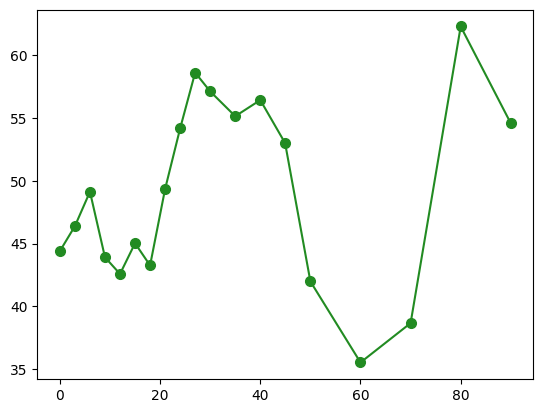

In [15]:
if __name__ == "__main__":
    # Демонстрация: задаем любые файлы и вешаем на них абсолютно любые метаданные
    experiments_data = [
        {
            "filter": "1_0_F.png", 
            "nofilter": "1_0.png", 
            "meta": {"distance": 0.0}
        },
        {
            "filter": "1_3_F.png", 
            "nofilter": "1_3.png", 
            "meta": {"distance": 3.0}
        },
        {
            "filter": "1_6_F.png", 
            "nofilter": "1_6.png", 
            "meta": {"distance": 6.0}
        },
        {
            "filter": "1_9_F.png", 
            "nofilter": "1_9.png", 
            "meta": {"distance": 9.0}
        },
        {
            "filter": "1_12_F.png", 
            "nofilter": "1_12.png", 
            "meta": {"distance": 12.0}
        },
        {
            "filter": "1_15_F.png", 
            "nofilter": "1_15.png", 
            "meta": {"distance": 15.0}
        },
        {
            "filter": "1_18_F.png", 
            "nofilter": "1_18.png", 
            "meta": {"distance": 18.0}
        },
        {
            "filter": "1_21_F.png", 
            "nofilter": "1_21.png", 
            "meta": {"distance": 21.0}
        },
        {
            "filter": "1_24_F.png", 
            "nofilter": "1_24.png", 
            "meta": {"distance": 24.0}
        },
        {
            "filter": "1_27_F.png", 
            "nofilter": "1_27.png", 
            "meta": {"distance": 27.0}
        },
        {
            "filter": "1_30_F.png", 
            "nofilter": "1_30.png", 
            "meta": {"distance": 30.0}
        },
        {
            "filter": "1_35_F.png", 
            "nofilter": "1_35.png", 
            "meta": {"distance": 35.0}
        },
        {
            "filter": "1_40_F.png", 
            "nofilter": "1_40.png", 
            "meta": {"distance": 40.0}
        },
        {
            "filter": "1_44.95_F.png", 
            "nofilter": "1_44.95.png", 
            "meta": {"distance": 44.95}
        },
        {
            "filter": "1_50_F.png", 
            "nofilter": "1_50.png", 
            "meta": {"distance": 50.0}
        },
        {
            "filter": "1_60_F.png", 
            "nofilter": "1_60.png", 
            "meta": {"distance": 60.0}
        },
        {
            "filter": "1_70_F.png", 
            "nofilter": "1_70.png", 
            "meta": {"distance": 70.0}
        },
        {
            "filter": "1_80_F.png", 
            "nofilter": "1_80.png", 
            "meta": {"distance": 80.0}
        },
        {
            "filter": "1_90_F.png", 
            "nofilter": "1_90.png", 
            "meta": {"distance": 90.0}
        }
    ]

    config_params = {
        "left": 280, "right": 430,
        "top": 180, "bottom": 320,
        "target_wavelength": 808.0,
        "stripe_width": 3,
        "savgol_window": 21,       
        "savgol_poly": 7,          
        "peak_prominence": 0.05,   
        "valley_prominence": 0.05, 
        "peak_distance": 6,        
        "peak_height_min": 0.12,   
        "output_dir": "analysis_output"
    }

    # Инициализируем анализатор серии. Указываем, по какому именно параметру строить финальные графики.
    # Например, хотим графики зависимости от дистанции:
    batch_manager = SpectroscopyBatchAnalyzer(output_dir=config_params["output_dir"], x_param="slit_size")
    
    # Если бы вы хотели отследить влияние размера щели, вы бы написали:
    # batch_manager = SpectroscopyBatchAnalyzer(output_dir=config_params["output_dir"], x_param="slit_size")

    for item in experiments_data:
        batch_manager.add_experiment(
            CrystalExperiment(
                filter_filename=item["filter"], 
                nofilter_filename=item["nofilter"], 
                metadata=item["meta"], 
                config=config_params
            )
        )

    batch_manager.process_all()


# 2. Получаем заветную табличку!
    df = batch_manager.to_dataframe()
    df 



In [ ]:
df

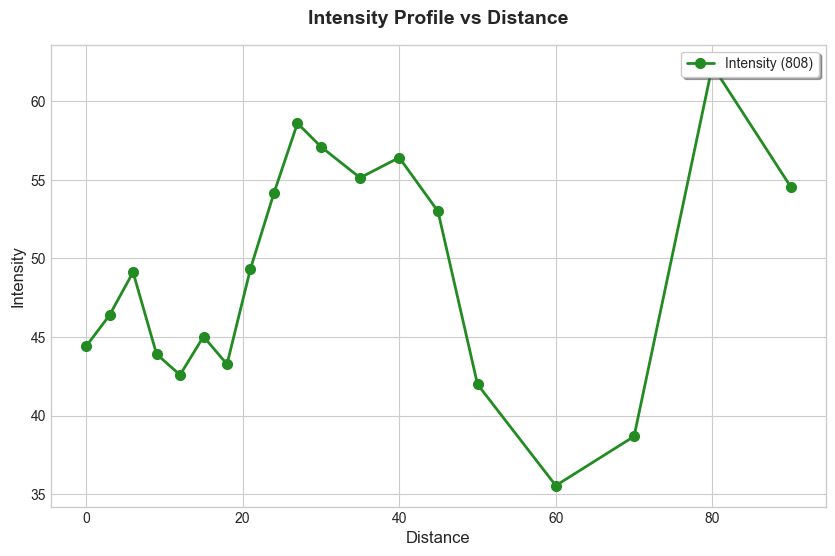

In [ ]:

# Setting a nice style
plt.style.use('seaborn-v0_8-whitegrid') # or 'ggplot'

plt.figure(figsize=(10, 6))

plt.plot(df["distance"], df["intensity_808_exact"], "o-",
         color="forestgreen", markersize=7, linewidth=2,
         label="Intensity (808)")

# Labels and Title
plt.xlabel("Distance", fontsize=12)
plt.ylabel("Intensity", fontsize=12)
plt.title("Intensity Profile vs Distance", fontsize=14, fontweight='bold', pad=15)

# Legend
plt.legend(loc="upper right", frameon=True, shadow=True)